# Installation and configuration of IBL packages

In [29]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pickle
from pathlib import Path


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

#all_trials = pd.read_parquet(Path("notebook_outputs") / "all_trials_cached.parquet")

In [30]:
import pickle

with open("notebook_outputs/q4_workspace.pkl", "rb") as f:
    globals().update(pickle.load(f))

# Q5. Does behavior change with the number of rewards received?

That matters because Q4 already contains the updated Q3 section with:

```text
previous_choice x previous_reward
```

So the Q5 model must include the Q3 interaction term, then add reward/time state variables.

The full Q5 model is:

$$
\begin{aligned}
P(\mathrm{choice}=1)=\sigma\Bigl(
&\beta_0+\beta_1\,\mathrm{signed\_contrast} \\
&+\beta_2\,\mathrm{previous\_choice} \\
&+\beta_3\,\mathrm{previous\_reward} \\
&+\beta_4\,(\mathrm{previous\_choice}\times\mathrm{previous\_reward}) \\
&+\beta_5\,\mathrm{trial\_fraction} \\
&+\beta_6\,\mathrm{reward\_fraction} \\
&+\beta_7\,(\mathrm{trial\_fraction}\times\mathrm{signed\_contrast}) \\
&+\beta_8\,(\mathrm{reward\_fraction}\times\mathrm{signed\_contrast})
\Bigr)
\end{aligned}
$$

Important code note:

In the code, `previous_choice` and `previous_reward` are represented by centered variables:

```text
previous_choice  -> prev_choice_centered
previous_reward  -> prev_reward_centered
interaction      -> prev_choice_x_reward
```

This is the same Q3 history information, but coded as `-1/+1` for cleaner interaction interpretation.

Q5 asks:

```text
After accounting for contrast, previous choice, previous reward,
and previous_choice x previous_reward, do reward/time state variables
explain additional behavior?
```

In simple words:

- Q3 interaction tests win-stay / lose-shift-like history effects.
- Q4 tests whether those parameters are stationary within a session.
- Q5 tests whether behavior changes with accumulated rewards or session progress.

The key Q5 variables are:

- `trial_fraction`: how far through the session the trial is
- `reward_fraction`: how many session rewards were already received before this trial
- `trial_fraction_x_contrast`: whether stimulus sensitivity changes over time
- `reward_fraction_x_contrast`: whether stimulus sensitivity changes after many rewards


## Q5-1. Create Q5 data from Q4 baseline

I do not change `df_q4` or old Q3/Q4 results.

For Q5, I make a new copy called `df_q5`.

Because Q3 changed, the baseline predictors are now:

```text
signed_contrast
prev_choice_centered
prev_reward_centered
prev_choice_x_reward
```

This means Q5 compares against the updated Q3 interaction model, not the older Q3 model.


In [31]:
# Q5 data copy. Do not change df_q4.

df_q5 = df_q4.copy(deep=True)

# Make sure the centered Q3 interaction columns exist.
# They should already exist because Q4 uses the updated Q3 interaction data.
if 'prev_choice_centered' not in df_q5.columns:
    df_q5['prev_choice_centered'] = df_q5['prev_choice_binary'].astype(float) * 2 - 1

if 'prev_reward_centered' not in df_q5.columns:
    df_q5['prev_reward_centered'] = df_q5['prev_rewarded'].astype(float) * 2 - 1

if 'prev_choice_x_reward' not in df_q5.columns:
    df_q5['prev_choice_x_reward'] = (
        df_q5['prev_choice_centered']
        * df_q5['prev_reward_centered']
    )

q5_group_cols = ['subject', 'session']

q5_sort_columns = [
    col for col in ['subject', 'session_start_time', 'session', 'intervals_0']
    if col in df_q5.columns
]

df_q5 = df_q5.sort_values(q5_sort_columns).copy(deep=True)

q5_baseline_features = [
    'signed_contrast',
    'prev_choice_centered',
    'prev_reward_centered',
    'prev_choice_x_reward'
]

print('Q5 starting data shape:', df_q5.shape)
print('Q5 baseline features:', q5_baseline_features)

display(
    df_q5[[
        'subject',
        'session',
        'choice_binary'
    ] + q5_baseline_features].head()
)


Q5 starting data shape: (2129698, 43)
Q5 baseline features: ['signed_contrast', 'prev_choice_centered', 'prev_reward_centered', 'prev_choice_x_reward']


,subject,session,choice_binary,signed_contrast,prev_choice_centered,prev_reward_centered,prev_choice_x_reward
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,0.0625,1.0,-1.0,-1.0
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,-0.1250,1.0,1.0,1.0
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,-0.0000,1.0,-1.0,-1.0
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0,-0.0000,1.0,-1.0,-1.0
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0,-0.2500,-1.0,1.0,-1.0


## Q5-2. Create trial fraction

`trial_fraction` shows where the trial is inside the session.

```text
0   = beginning of session
0.5 = middle of session
1   = end of session
```

This tests whether behavior changes over time, even without using reward count.


In [32]:
df_q5['trial_number'] = (
    df_q5
    .groupby(q5_group_cols)
    .cumcount()
)

q5_max_trial_number = (
    df_q5
    .groupby(q5_group_cols)['trial_number']
    .transform('max')
)

df_q5['trial_fraction'] = (
    df_q5['trial_number']
    / q5_max_trial_number.replace(0, np.nan)
)

display(df_q5[['subject', 'session', 'trial_number', 'trial_fraction']].head())


,subject,session,trial_number,trial_fraction
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0,0.000000
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,0.001076
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,2,0.002153
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,3,0.003229
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,4,0.004306


## Q5-3. Create reward fraction

`reward_fraction` measures accumulated rewards before the current trial.

Important: we count rewards **before** the current trial, not including the current trial.

```text
reward_fraction = rewards already received before this trial / total rewards in session
```

This tests whether behavior changes as the mouse receives more rewards.


In [33]:
df_q5['rewarded'] = (df_q5['feedbackType'] == 1).astype(int)

df_q5['cum_rewards_before'] = (
    df_q5
    .groupby(q5_group_cols)['rewarded']
    .cumsum()
    - df_q5['rewarded']
)

q5_total_rewards = (
    df_q5
    .groupby(q5_group_cols)['rewarded']
    .transform('sum')
)

df_q5['reward_fraction'] = (
    df_q5['cum_rewards_before']
    / q5_total_rewards.replace(0, np.nan)
)

display(
    df_q5[[
        'subject',
        'session',
        'rewarded',
        'cum_rewards_before',
        'reward_fraction'
    ]].head()
)


,subject,session,rewarded,cum_rewards_before,reward_fraction
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,0,0.000000
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0,1,0.001351
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0,1,0.001351
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,1,0.001351
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1,2,0.002703


## Q5-4. Create reward/time interaction features

Q5 adds two interaction terms with contrast:

```text
trial_fraction x signed_contrast
reward_fraction x signed_contrast
```

Why?

The mouse may not only become more biased over time or after rewards.
It may also use stimulus contrast differently.

Examples:

- If `reward_fraction_x_contrast` is negative, the mouse may use contrast less strongly after many rewards.
- If `trial_fraction_x_contrast` is negative, the mouse may use contrast less strongly later in the session.


In [34]:
df_q5 = df_q5.dropna(
    subset=['trial_fraction', 'reward_fraction']
).copy(deep=True)

df_q5['trial_fraction_x_contrast'] = (
    df_q5['trial_fraction']
    * df_q5['signed_contrast']
)

df_q5['reward_fraction_x_contrast'] = (
    df_q5['reward_fraction']
    * df_q5['signed_contrast']
)

q5_state_features = q5_baseline_features + [
    'trial_fraction',
    'reward_fraction',
    'trial_fraction_x_contrast',
    'reward_fraction_x_contrast'
]

q5_time_reward_corr = (
    df_q5[['trial_fraction', 'reward_fraction']]
    .corr()
    .iloc[0, 1]
)

print('Q5 data after state-feature cleanup:', df_q5.shape)
print('Q5 state features:', q5_state_features)
print('Correlation between trial_fraction and reward_fraction:', round(q5_time_reward_corr, 3))

if q5_time_reward_corr > 0.9:
    print('Very high correlation: reward and time are difficult to separate.')
elif q5_time_reward_corr > 0.6:
    print('Moderate/high correlation: reward and time effects may be partly mixed.')
else:
    print('Lower correlation: reward and time are easier to separate.')


Q5 data after state-feature cleanup: (2129698, 50)
Q5 state features: ['signed_contrast', 'prev_choice_centered', 'prev_reward_centered', 'prev_choice_x_reward', 'trial_fraction', 'reward_fraction', 'trial_fraction_x_contrast', 'reward_fraction_x_contrast']
Correlation between trial_fraction and reward_fraction: 0.998
Very high correlation: reward and time are difficult to separate.


## Q5-5. Fit baseline and Q5 models

To compare fairly, I fit two models on the same rows and same train/test split for each mouse.

Baseline model from updated Q3:

```text
choice ~ signed_contrast
       + previous_choice
       + previous_reward
       + previous_choice x previous_reward
```

Full Q5 model:

```text
choice ~ signed_contrast
       + previous_choice
       + previous_reward
       + previous_choice x previous_reward
       + trial_fraction
       + reward_fraction
       + trial_fraction x signed_contrast
       + reward_fraction x signed_contrast
```

So Q5 is not replacing Q3. Q5 is asking whether reward/time variables add anything **beyond** the updated Q3 interaction baseline.

If Q5 has higher held-out log likelihood, reward/time state variables add predictive information beyond the updated Q3 interaction baseline.


In [35]:
q5_required_columns = q5_state_features + ['choice_binary']
df_q5_model = df_q5.dropna(subset=q5_required_columns).copy(deep=True)

q5_models = {}

for subject, mouse_data in df_q5_model.groupby('subject'):

    X_baseline = mouse_data[q5_baseline_features]
    X_state = mouse_data[q5_state_features]
    y = mouse_data['choice_binary']

    if len(y) < 100:
        continue

    if y.nunique() < 2:
        continue

    if y.value_counts().min() < 2:
        continue

    train_index, test_index = train_test_split(
        mouse_data.index,
        test_size=0.2,
        random_state=0,
        stratify=y
    )

    X_train_baseline = X_baseline.loc[train_index]
    X_test_baseline = X_baseline.loc[test_index]
    X_train_state = X_state.loc[train_index]
    X_test_state = X_state.loc[test_index]
    y_train = y.loc[train_index]
    y_test = y.loc[test_index]

    baseline_model = LogisticRegression(max_iter=1000)
    baseline_model.fit(X_train_baseline, y_train)
    baseline_class_1_index = list(baseline_model.classes_).index(1)
    p_test_baseline = baseline_model.predict_proba(X_test_baseline)[:, baseline_class_1_index]
    log_likelihood_baseline = -log_loss(y_test, p_test_baseline, labels=[0, 1])

    state_model = LogisticRegression(max_iter=1000)
    state_model.fit(X_train_state, y_train)
    state_class_1_index = list(state_model.classes_).index(1)
    p_test_state = state_model.predict_proba(X_test_state)[:, state_class_1_index]
    log_likelihood_q5 = -log_loss(y_test, p_test_state, labels=[0, 1])

    q5_models[subject] = {
        'baseline_model': baseline_model,
        'q5_model': state_model,
        'log_likelihood_baseline_q3_interaction': log_likelihood_baseline,
        'log_likelihood_q5': log_likelihood_q5,
        'q5_improvement_vs_baseline': log_likelihood_q5 - log_likelihood_baseline,
        'n_train': len(y_train),
        'n_test': len(y_test)
    }

    for feature_name, weight in zip(q5_state_features, state_model.coef_[0]):
        q5_models[subject][f'{feature_name}_weight_q5'] = weight

    q5_models[subject]['bias_q5'] = state_model.intercept_[0]

print('Fit Q5 models for', len(q5_models), 'mice')


Fit Q5 models for 119 mice


## Q5-6. Results table

Main columns:

- `log_likelihood_baseline_q3_interaction`: updated Q3 interaction baseline
- `log_likelihood_q5`: Q5 reward/time model
- `q5_improvement_vs_baseline`: whether reward/time improves prediction


In [36]:
q5_results = []

for subject, result in q5_models.items():
    row = {'subject': subject}
    row.update({k: v for k, v in result.items() if k not in ['baseline_model', 'q5_model']})
    q5_results.append(row)

q5_results_df = pd.DataFrame(q5_results)

display(q5_results_df.head())

print('Mean baseline Q3 interaction log likelihood:', q5_results_df['log_likelihood_baseline_q3_interaction'].mean())
print('Mean Q5 log likelihood:', q5_results_df['log_likelihood_q5'].mean())
print('Mean Q5 improvement:', q5_results_df['q5_improvement_vs_baseline'].mean())
print('Mice improved:', (q5_results_df['q5_improvement_vs_baseline'] > 0).sum(), '/', len(q5_results_df))


,subject,log_likelihood_baseline_q3_interaction,log_likelihood_q5,q5_improvement_vs_baseline,n_train,n_test,signed_contrast_weight_q5,prev_choice_centered_weight_q5,prev_reward_centered_weight_q5,prev_choice_x_reward_weight_q5,trial_fraction_weight_q5,reward_fraction_weight_q5,trial_fraction_x_contrast_weight_q5,reward_fraction_x_contrast_weight_q5,bias_q5
0,CSHL045,-0.406107,-0.405964,0.000143,14346,3587,6.703820,0.767147,0.071655,0.267102,0.672747,-0.846902,0.927079,0.749402,0.021208
1,CSHL046,-0.430546,-0.428583,0.001964,11595,2899,6.564385,0.841086,0.169329,0.171957,-0.188024,-0.324316,-1.417302,-1.745181,0.116834
2,CSHL047,-0.410913,-0.410991,-0.000078,12898,3225,4.876011,0.720620,-0.291594,-0.017387,-0.048895,-0.093344,0.606010,-0.379573,-0.764959
3,CSHL049,-0.408931,-0.408301,0.000630,12478,3120,7.476164,0.639832,0.006853,0.149122,0.554568,-0.899147,-0.154239,-1.280198,0.573700
4,CSHL051,-0.429854,-0.428234,0.001620,12105,3027,4.375964,0.975529,-0.043972,0.202031,2.928085,-3.001142,0.017391,-1.706294,-0.430871


Mean baseline Q3 interaction log likelihood: -0.42674689234925417
Mean Q5 log likelihood: -0.4223692691885975
Mean Q5 improvement: 0.004377623160656624
Mice improved: 104 / 119


## Q5-7. Visualize improvement

Positive values mean Q5 predicts better than the updated Q3 interaction baseline.


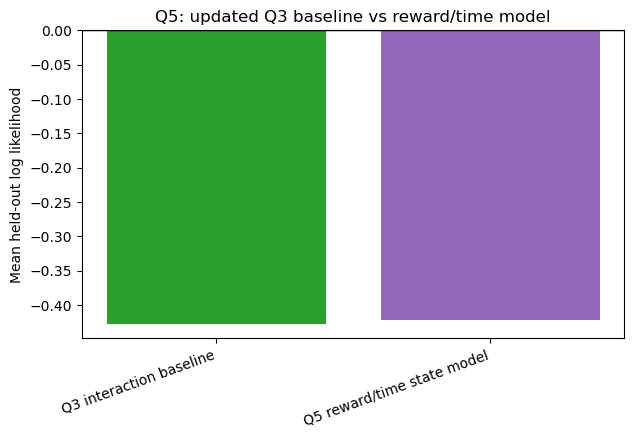

,model,mean_log_likelihood
0,Q3 interaction baseline,-0.426747
1,Q5 reward/time state model,-0.422369


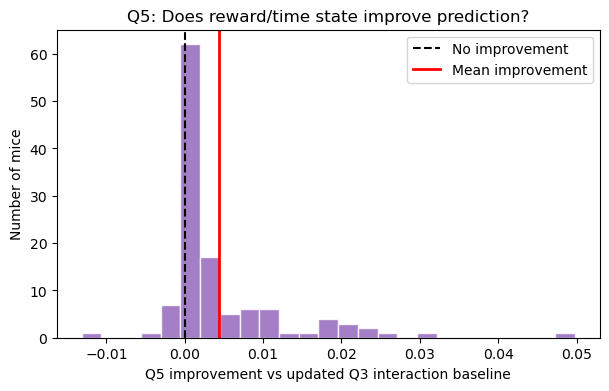

Mean improvement: 0.004377623160656624


In [37]:
q5_mean_scores_df = pd.DataFrame({
    'model': [
        'Q3 interaction baseline',
        'Q5 reward/time state model'
    ],
    'mean_log_likelihood': [
        q5_results_df['log_likelihood_baseline_q3_interaction'].mean(),
        q5_results_df['log_likelihood_q5'].mean()
    ]
})

plt.figure(figsize=(7, 4))
plt.bar(
    q5_mean_scores_df['model'],
    q5_mean_scores_df['mean_log_likelihood'],
    color=['tab:green', 'tab:purple']
)
plt.ylabel('Mean held-out log likelihood')
plt.title('Q5: updated Q3 baseline vs reward/time model')
plt.xticks(rotation=20, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.show()

display(q5_mean_scores_df)

q5_mean_improvement = q5_results_df['q5_improvement_vs_baseline'].mean()

plt.figure(figsize=(7, 4))
plt.hist(
    q5_results_df['q5_improvement_vs_baseline'],
    bins=25,
    color='tab:purple',
    edgecolor='white',
    alpha=0.85
)
plt.axvline(0, color='black', linestyle='--', label='No improvement')
plt.axvline(q5_mean_improvement, color='red', linewidth=2, label='Mean improvement')
plt.xlabel('Q5 improvement vs updated Q3 interaction baseline')
plt.ylabel('Number of mice')
plt.title('Q5: Does reward/time state improve prediction?')
plt.legend()
plt.show()

print('Mean improvement:', q5_mean_improvement)


## Q5-8. Final conclusion

This cell prints the final answer for Q5.


In [38]:
mean_q5_improvement = q5_results_df['q5_improvement_vs_baseline'].mean()

mean_reward_weight_q5 = q5_results_df['reward_fraction_weight_q5'].mean()
mean_trial_weight_q5 = q5_results_df['trial_fraction_weight_q5'].mean()
mean_reward_contrast_weight_q5 = q5_results_df['reward_fraction_x_contrast_weight_q5'].mean()
mean_trial_contrast_weight_q5 = q5_results_df['trial_fraction_x_contrast_weight_q5'].mean()

print('Q5 final answer')
print('-----------------')
print('Mean Q5 improvement vs updated Q3 interaction baseline:', mean_q5_improvement)
print('Mean reward_fraction weight:', mean_reward_weight_q5)
print('Mean trial_fraction weight:', mean_trial_weight_q5)
print('Mean reward_fraction x contrast weight:', mean_reward_contrast_weight_q5)
print('Mean trial_fraction x contrast weight:', mean_trial_contrast_weight_q5)
print()

if mean_q5_improvement > 0:
    print('Q5 conclusion: reward/time variables improve prediction beyond the updated Q3 interaction baseline.')
else:
    print('Q5 conclusion: reward/time variables do not improve prediction beyond the updated Q3 interaction baseline on average.')

if abs(mean_reward_weight_q5) > 0.05 or abs(mean_reward_contrast_weight_q5) > 0.05:
    print('Reward interpretation: accumulated rewards have a noticeable effect in the Q5 model.')
    print('This supports possible internal-state changes related to satiety, reward accumulation, or motivation.')
else:
    print('Reward interpretation: accumulated reward effects are weak in the Q5 model.')

if abs(mean_trial_weight_q5) > 0.05 or abs(mean_trial_contrast_weight_q5) > 0.05:
    print('Time interpretation: session progress also has a noticeable effect.')
    print('This means reward effects may be mixed with fatigue, boredom, or time in session.')
else:
    print('Time interpretation: session-progress effects are weak in the Q5 model.')

print()
print('Why this Q5 is different from old Q5:')
print('Old Q5 compared reward/time variables to the older Q3 history model.')
print('Q5 compares reward/time variables to the updated Q3 interaction model from the Q4 baseline file.')


Q5 final answer
-----------------
Mean Q5 improvement vs updated Q3 interaction baseline: 0.004377623160656624
Mean reward_fraction weight: -0.29665333994342835
Mean trial_fraction weight: 0.24755770013934275
Mean reward_fraction x contrast weight: -0.4657172736568763
Mean trial_fraction x contrast weight: 0.029566605750799464

Q5 conclusion: reward/time variables improve prediction beyond the updated Q3 interaction baseline.
Reward interpretation: accumulated rewards have a noticeable effect in the Q5 model.
This supports possible internal-state changes related to satiety, reward accumulation, or motivation.
Time interpretation: session progress also has a noticeable effect.
This means reward effects may be mixed with fatigue, boredom, or time in session.

Why this Q5 is different from old Q5:
Old Q5 compared reward/time variables to the older Q3 history model.
Q5 compares reward/time variables to the updated Q3 interaction model from the Q4 baseline file.


In [39]:
import pickle
import types
from pathlib import Path

Path("notebook_outputs").mkdir(exist_ok=True)

workspace = {}

for name, value in list(globals().items()):
    if name.startswith("_"):
        continue
    if name in ["In", "Out", "exit", "quit", "get_ipython"]:
        continue
    if isinstance(value, types.ModuleType):
        continue
    if callable(value):
        continue

    try:
        pickle.dumps(value)
        workspace[name] = value
    except Exception:
        pass

with open("notebook_outputs/q5_workspace.pkl", "wb") as f:
    pickle.dump(workspace, f)

print("saved q5")

saved q5
